In [17]:
import sys 
from pathlib import Path
sys.path.append(str(Path(__name__).resolve().parents[2]))
import importlib
import utils 
import utils.dataset 
importlib.reload(utils.dataset)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons, get_template_from_geneset
from utils.dna import Genes, create_template_from_genes
from pathlib import Path
from utils.dataset import TEST_GENESET_GENES, EASY_GENESET_GENES, MEDIUIM_GENESET_GENES, EASY_V2_GENESET_GENES
import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
from utils.dataset import get_raw_dataset
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
ROOT_DIR = Path(__name__).resolve().parents[2]
ROOT_DIR

PosixPath('/Users/czyjtu/dev/prompt2avatar')

In [5]:
MEDIUIM_GENESET_GENES[30]

'expression_other.cheek_wrinkles_both_01'

In [8]:
DATASET_NAME = 'medium_geneset_embeddings'
DATASET_DIR = DATA_DIR / DATASET_NAME
EXPERIMENT_DIR = ROOT_DIR / 'experiments' / DATASET_NAME

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

def mse_matrix(A, B):
    f = A.shape[1]  # Number of facial features
    mse_values = np.zeros(f)  # Initialize the MSE vector to store MSE for each facial feature
    r2_values = np.zeros(f)  # Initialize the R2 vector to store R2 for each facial feature
    models = []
    for i in tqdm(range(f), total=f):  # Iterate over each facial feature in A
        reg = LinearRegression().fit(B, A[:, i])  # Train model to predict the i-th facial feature using all dimensions in B
        pred = reg.predict(B)  # Predict the i-th facial feature
        mse_values[i] = mean_squared_error(A[:, i], pred)  # Calculate the MSE for the i-th facial feature
        r2_values[i] = r2_score(A[:, i], pred)
        models.append(reg)
    return mse_values, r2_values, models


d = "test"
Xt, Yt = get_raw_dataset(d)
mse_mt, r2_mt, models_mt = mse_matrix(MinMaxScaler().fit_transform(Xt),Yt)
mse_mt, r2_mt

100%|██████████| 3/3 [00:02<00:00,  1.21it/s]


(array([6.89245515e-05, 1.55435692e-04, 2.47901636e-04]),
 array([0.99809729, 0.98632042, 0.99782939]))

In [32]:
d = "easy"
Xe, Ye = get_raw_dataset(d)
mse_me, r2_me, models_me = mse_matrix(MinMaxScaler().fit_transform(Xe),Ye)
mse_me, r2_me

100%|██████████| 13/13 [00:14<00:00,  1.14s/it]


(array([0.00027003, 0.00033983, 0.00112809, 0.00086755, 0.00106659,
        0.00040471, 0.00132484, 0.00052141, 0.00024904, 0.0003723 ,
        0.0004126 , 0.00021167, 0.00082451]),
 array([0.99251391, 0.97508452, 0.89953235, 0.97485734, 0.90557884,
        0.98753186, 0.94831555, 0.97137618, 0.98751186, 0.98703105,
        0.97426682, 0.98852911, 0.99296874]))

In [36]:
medium_dataset = ProcessedDataset(DATA_DIR / 'medium_geneset_embeddings')

100%|██████████| 7/7 [00:00<00:00, 40.24it/s]


In [33]:
d = "medium"
Xm, Ym = get_raw_dataset(d)
mse_mm, r2_mm, models_mm = mse_matrix(MinMaxScaler().fit_transform(Xm),Ym)
mse_mm, r2_mm

100%|██████████| 35/35 [00:35<00:00,  1.01s/it]


(array([0.01296352, 0.01289487, 0.01316882, 0.01080842, 0.0106561 ,
        0.01128368, 0.01965659, 0.01958012, 0.01975062, 0.03423793,
        0.0553552 , 0.05561362, 0.03261682, 0.02235364, 0.0267598 ,
        0.0108055 , 0.0220146 , 0.01073432, 0.03015885, 0.02427714,
        0.01689986, 0.01149756, 0.01134988, 0.01861503, 0.02704353,
        0.03922748, 0.0151357 , 0.01753891, 0.02438559, 0.02011106,
        0.        , 0.11023759, 0.10615936, 0.06374118, 0.06374118]),
 array([0.0544489 , 0.05445091, 0.04945905, 0.0377497 , 0.04988103,
        0.03862464, 0.04741065, 0.04359025, 0.03459837, 0.0511894 ,
        0.05708647, 0.05482928, 0.05456885, 0.05523317, 0.05396499,
        0.04401572, 0.05382026, 0.05449249, 0.07079813, 0.0530212 ,
        0.0717032 , 0.02195411, 0.04766647, 0.06684472, 0.0577584 ,
        0.06550858, 0.05617359, 0.05005689, 0.05396415, 0.05040529,
        1.        , 0.07163245, 0.094397  , 0.06591858, 0.06591858]))

In [18]:
d = "easyv2"
Xee, Yee = get_raw_dataset(d)
mse_mee, r2_mee, models_mee = mse_matrix(MinMaxScaler().fit_transform(Xee),Yee)
mse_mee, r2_mee

100%|██████████| 24/24 [00:25<00:00,  1.06s/it]


(array([0.03413182, 0.01288099, 0.01065245, 0.03257753, 0.0107518 ,
        0.03014478, 0.02422865, 0.01688418, 0.01859168, 0.0270319 ,
        0.01511387, 0.01751223, 0.10609884, 0.02006865, 0.01947359,
        0.01062887, 0.05544564, 0.        , 0.02198906, 0.01960737,
        0.03921719, 0.01129209, 0.01149141, 0.01118081]),
 array([0.05317174, 0.05573286, 0.05099096, 0.05596946, 0.04843317,
        0.0714523 , 0.05463392, 0.0731736 , 0.06794663, 0.05831981,
        0.05743606, 0.05109672, 0.09539852, 0.05304234, 0.04888878,
        0.0525346 , 0.05726731, 1.        , 0.05526208, 0.04986364,
        0.06601846, 0.05219352, 0.02307348, 0.04710421]))

In [46]:
d = "original"
dataset = ProcessedDataset(DATA_DIR / "dataset_2024_04_07_embeddings")
matching_dnas = dataset.dna
sub_genes = [set(dna.flatten().keys()) for dna in matching_dnas]
all_genes = set.union(*sub_genes)
common_genes = set.intersection(*sub_genes)
genes_to_use = sorted(common_genes)
vectorized_dnas = np.array([dna.asarray(keys=genes_to_use) for dna in matching_dnas])
from sklearn.preprocessing import minmax_scale

vectorized_dnas_scaled = minmax_scale(vectorized_dnas)
ok_index = []
ok_genes = []
for i, gen_name in zip(range(len(vectorized_dnas_scaled)), genes_to_use):
    a = vectorized_dnas_scaled[:, i]
    if np.all(np.isclose(a[0], a)):
        print(gen_name)
    else: 
        ok_index.append(i)
        ok_genes.append(gen_name)

vectorized_dnas_scaled_filtered = vectorized_dnas_scaled[:, ok_index]
Xall = vectorized_dnas_scaled_filtered
Yall = dataset.model2normalized_embeddings["arcface-r100"]
mse_all, r2_all, models_all = mse_matrix(Xall,Yall)
mse_all, r2_all

100%|██████████| 3/3 [00:00<00:00, 34.73it/s]


eye_accessory.normal_eyes
skin_color[1]
gene_bs_mouth_upper_lip_width.mouth_upper_lip_width_pos


100%|██████████| 92/92 [01:56<00:00,  1.27s/it]


(array([0.08259709, 0.02065841, 0.01269378, 0.02065841, 0.01269378,
        0.08319055, 0.06122518, 0.00930854, 0.02193805, 0.02402169,
        0.05289295, 0.03916808, 0.00409939, 0.00699309, 0.00457053,
        0.01713103, 0.0725938 , 0.01046964, 0.01193071, 0.00475297,
        0.01539283, 0.00552888, 0.01113459, 0.00550381, 0.0058245 ,
        0.01532481, 0.01116794, 0.00731676, 0.0108141 , 0.03628973,
        0.02212084, 0.00939945, 0.02901966, 0.01192746, 0.01472955,
        0.01613235, 0.02119644, 0.0160032 , 0.0183428 , 0.02431159,
        0.01202471, 0.00407938, 0.00622194, 0.0140274 , 0.00303823,
        0.01115273, 0.01040561, 0.01023287, 0.00347391, 0.01154075,
        0.00990067, 0.00860344, 0.00710133, 0.00632944, 0.00206211,
        0.01599312, 0.00213017, 0.00695021, 0.00792848, 0.00597837,
        0.00588835, 0.00941564, 0.00720693, 0.00711506, 0.00868272,
        0.00585411, 0.01740069, 0.00613177, 0.00469405, 0.01223653,
        0.00431938, 0.00924201, 0.00585264, 0.00

In [47]:
# test model trained on easy on medium
Xm_easy = Xm[:, [MEDIUIM_GENESET_GENES.index(feature) for feature in EASY_GENESET_GENES]]
Xm_easy = MinMaxScaler().fit(Xe).transform(Xm_easy)
for i, feature in enumerate(EASY_GENESET_GENES):
    medium_index = MEDIUIM_GENESET_GENES.index(feature)

    print(feature, medium_index)
    reg = models_me[i]
    pred = reg.predict(Ym)
    print("MSE: ", mean_squared_error(Xm_easy[:, i], pred))
    print("R2: ", r2_score(Xm_easy[:, i], pred))

gene_forehead_brow_height.forehead_brow_height_pos 9
MSE:  0.049423148395977744
R2:  -0.36962738648400273
gene_bs_cheek_forward.cheek_forward_pos 1
MSE:  0.025911725714079622
R2:  -0.9000437649053421
gene_chin_height.chin_height_pos 3
MSE:  0.020529060292657334
R2:  -0.8276585220181376
gene_head_height.head_height_pos 12
MSE:  0.043322463596591754
R2:  -0.255744796873941
gene_jaw_height.jaw_height_pos 15
MSE:  0.03354025888850636
R2:  -1.9673753952934048
gene_mouth_upper_lip_size.mouth_upper_lip_size_pos 18
MSE:  0.15349026129664559
R2:  -3.7290739526438044
gene_mouth_height.mouth_height_pos 19
MSE:  0.13742267781994427
R2:  -4.360447654057337
gene_mouth_width.mouth_width_pos 20
MSE:  0.1278306978859676
R2:  -6.02164395412969
gene_bs_nose_tip_angle.nose_tip_angle_pos 23
MSE:  0.020947158873328483
R2:  -0.050062667392209326
gene_bs_nose_height.nose_height_pos 24
MSE:  0.027204414480424106
R2:  0.0521527441613836
gene_eye_angle.eye_angle_pos 26
MSE:  0.06655653410981531
R2:  -3.150306597

In [49]:
# test model trained on easy on medium
Xm_easy = Xm[:, [MEDIUIM_GENESET_GENES.index(feature) for feature in EASY_GENESET_GENES]]
Xm_easy = minmax_scale(Xm_easy)
for i, feature in enumerate(EASY_GENESET_GENES):
    medium_index = MEDIUIM_GENESET_GENES.index(feature)
    if feature not in ok_genes:
        continue
    all_index = ok_genes.index(feature)
    print(feature, medium_index, all_index)
    reg = models_all[all_index]
    pred = reg.predict(Ym)
    print("MSE: ", mean_squared_error(Xm_easy[:, i], pred))
    print("STD: ", np.std(Xm_easy[:, i]))
    print("R2: ", r2_score(Xm_easy[:, i], pred))

gene_forehead_brow_height.forehead_brow_height_pos 9 50
MSE:  0.03823051969188915
STD:  0.18996079924825762
R2:  -0.05945429356315013
gene_bs_cheek_forward.cheek_forward_pos 1 43
MSE:  0.24198716125847478
STD:  0.11677943418656044
R2:  -16.744329420964622
gene_chin_height.chin_height_pos 3 72
MSE:  0.0605569774835706
STD:  0.1059831948684214
R2:  -4.391258751629001
gene_head_height.head_height_pos 12 28
MSE:  0.11546404078643423
STD:  0.1857401872567715
R2:  -2.3468403319291413
gene_jaw_height.jaw_height_pos 15 63
MSE:  0.05574272337591256
STD:  0.1063155914532658
R2:  -3.9316728997882686
gene_mouth_upper_lip_size.mouth_upper_lip_size_pos 18 21
MSE:  0.03655221035424609
STD:  0.18015750553258358
R2:  -0.1261828889830685
gene_mouth_height.mouth_height_pos 19 13
MSE:  0.13006541480049702
STD:  0.16011376644117004
R2:  -4.073462827982619
gene_mouth_width.mouth_width_pos 20 69
MSE:  0.0779043377169655
STD:  0.13492678678996134
R2:  -3.279226594059425
gene_bs_nose_tip_angle.nose_tip_angle_p

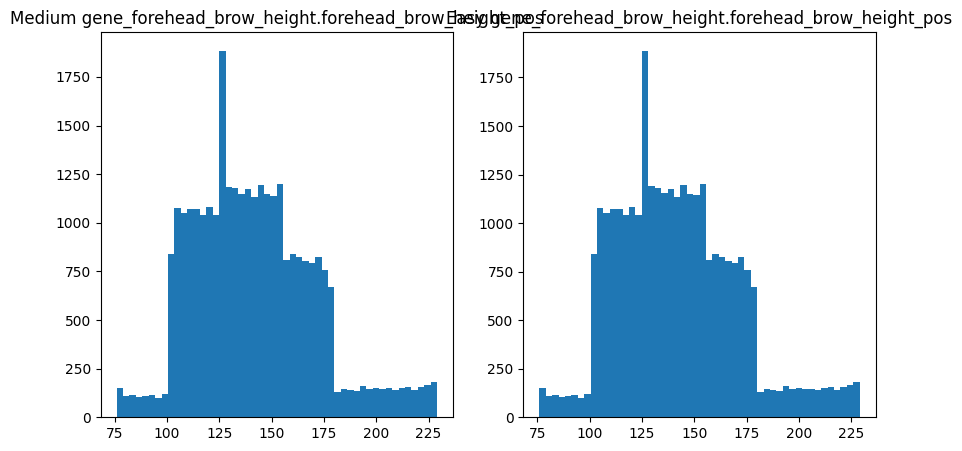

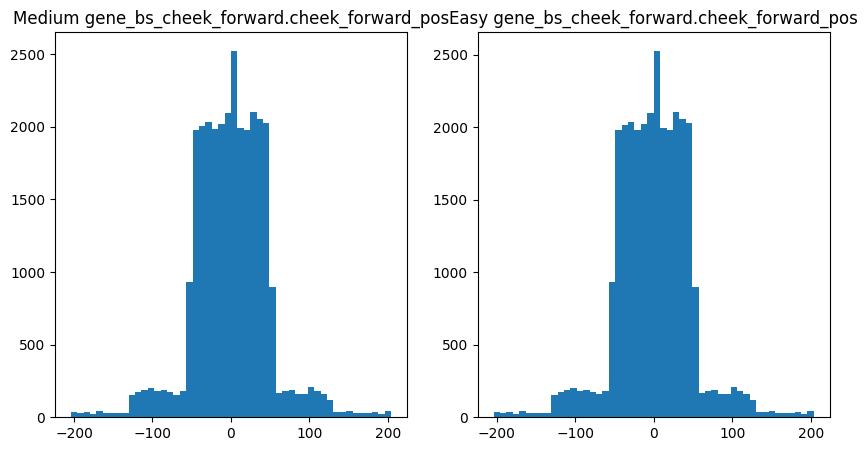

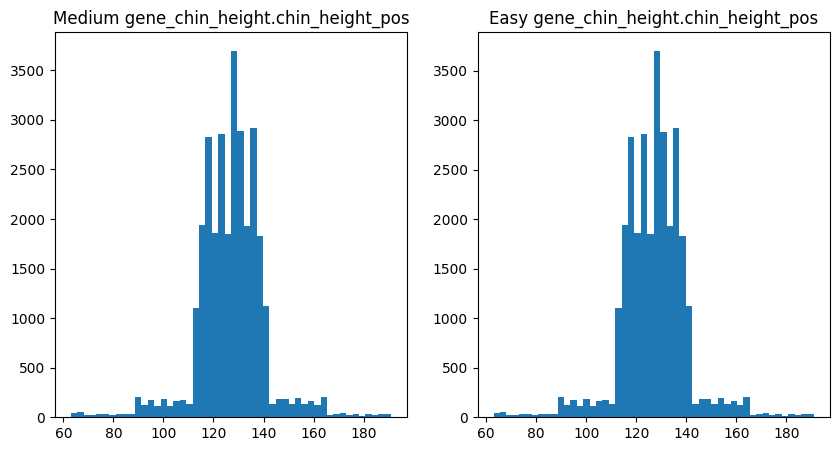

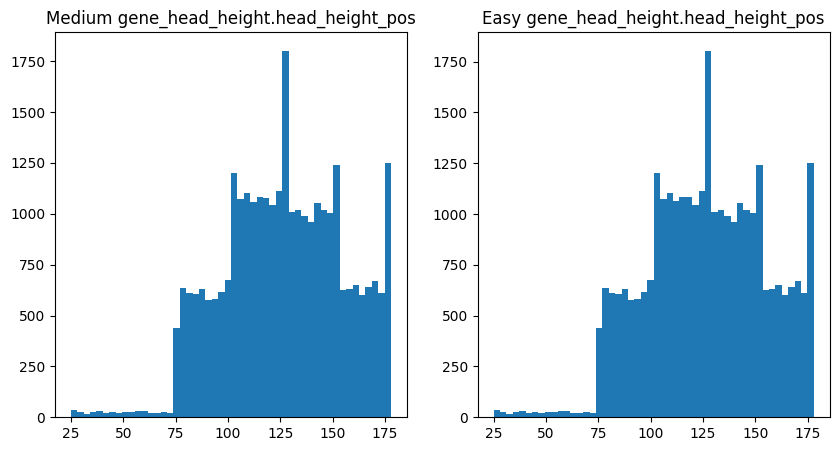

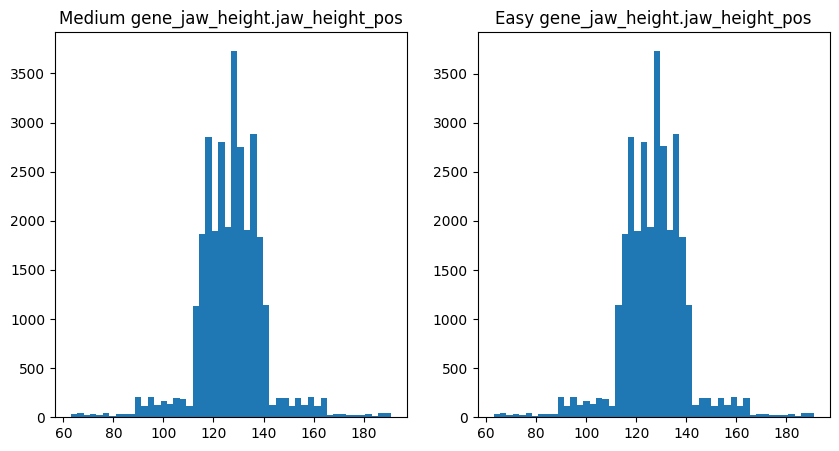

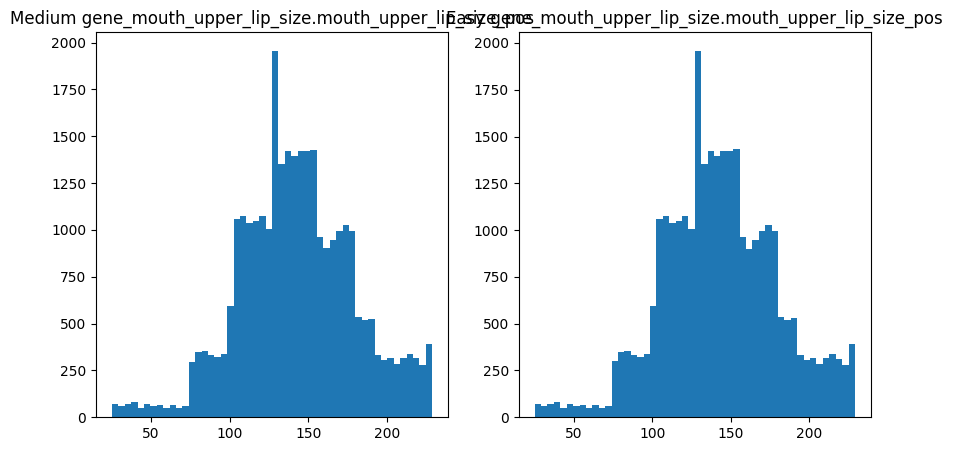

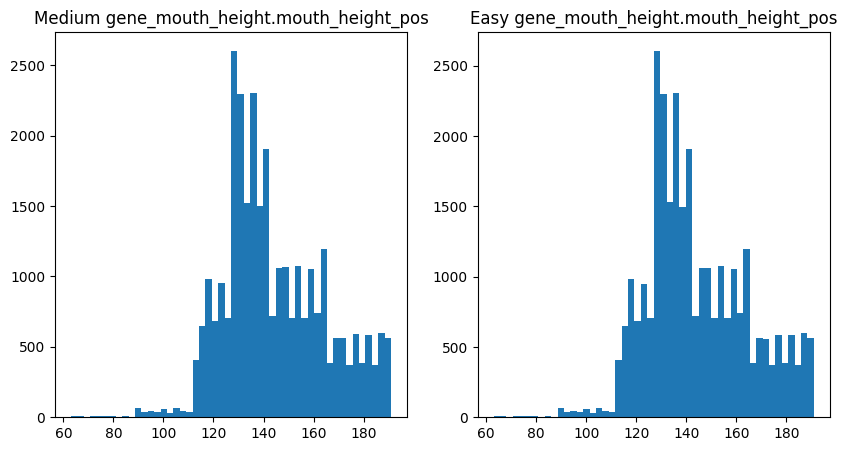

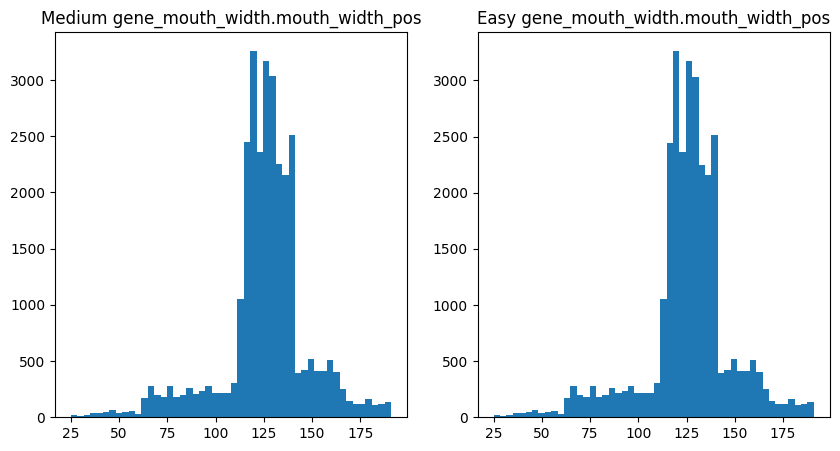

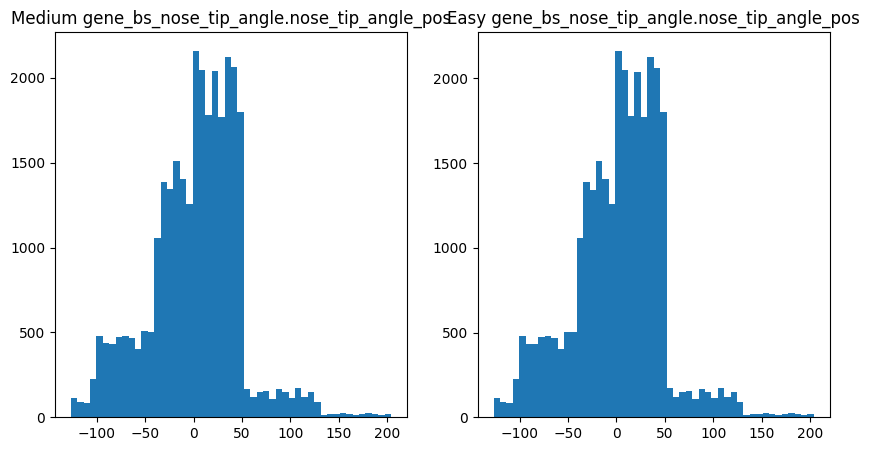

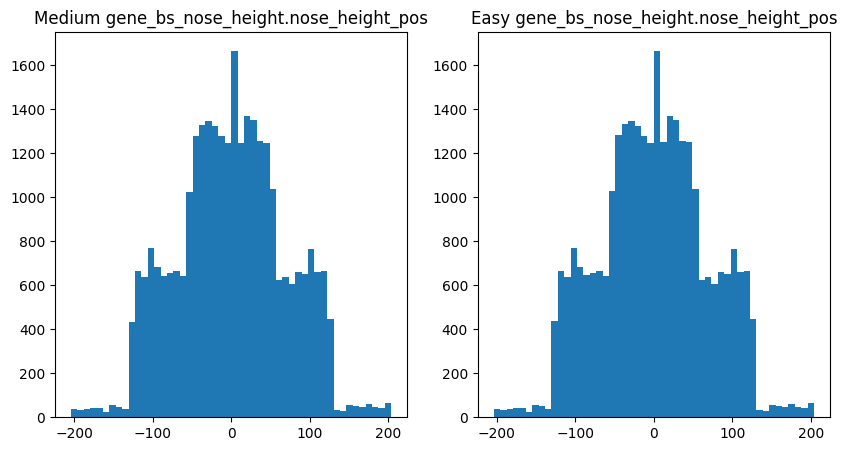

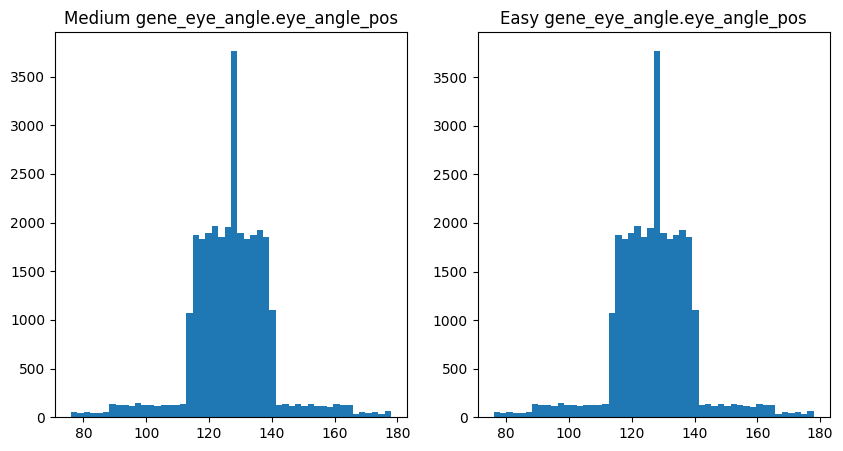

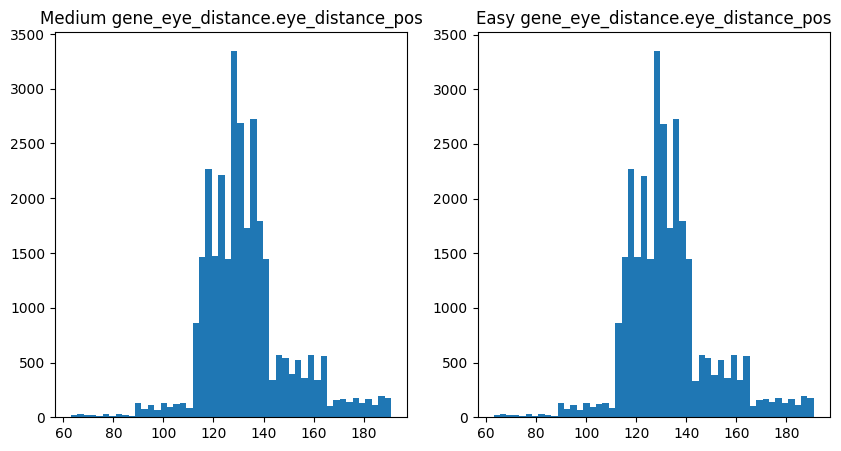

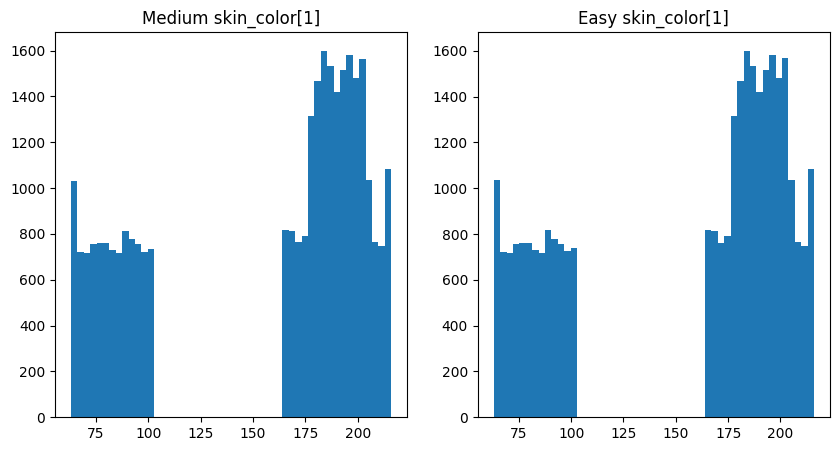

In [31]:
for i, feature in enumerate(EASY_GENESET_GENES):
    medium_index = MEDIUIM_GENESET_GENES.index(feature)
    medium_features = Xm[:, medium_index]
    easy_features = Xe[:, i]
    # side by side hisogram 
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].hist(medium_features, bins=50)
    axs[0].set_title(f"Medium {feature}")
    axs[1].hist(easy_features, bins=50)
    axs[1].set_title(f"Easy {feature}")
    plt.show()
    